In [1]:
import xarray as xr
import numpy as np
import sys,os
from pathlib import Path
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools.utils import dataarray_healpix_to_equatorial_latlon
from wave_tools import calculate_cross_spectrum, quick_cross_spectrum,remove_annual_cycle
from wave_tools.utils import  get_curve
from typing import Tuple, List, Dict
from metpy.units import units
import os

In [2]:
def _ocean():
    fraction = xr.open_dataarray(r'../processed_data/land_mask_2deg.nc')
    return fraction == 0
ocean_mask = _ocean()

In [3]:
def compute_grid_spacing(lat: np.ndarray, lon: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """计算网格间距 (m)"""
    R = 6.371e6  # 地球半径
    xlon, ylat = np.meshgrid(lon, lat)
    dlonx = np.gradient(xlon, axis=1)
    dlaty = np.gradient(ylat, axis=0)
    dx = R * np.cos(ylat * np.pi / 180) * dlonx * np.pi / 180
    dy = R * dlaty * np.pi / 180
    return dx, dy

def numpy_divergence(u: xr.DataArray, v: xr.DataArray, dx: np.ndarray, dy: np.ndarray) -> np.ndarray:
    """使用 NumPy 计算散度"""
    du_dx = np.gradient(u, axis=-1) * units('m/s') / dx[np.newaxis, :, :]
    dv_dy = np.gradient(v, axis=-2) * units('m/s') / dy[np.newaxis, :, :]
    return (du_dx + dv_dy).magnitude

def xarray_dataset(u,v):
    lat,lon = u.lat.values,u.lon.values
    dx,dy   = compute_grid_spacing(lat,lon)
    div     = numpy_divergence(u,v,dx,dy)
    
    return xr.DataArray(div,coords=u.coords,dims=u.dims).to_dataset(name='div')

def save_to_netcdf(u,v,path):
    div = xarray_dataset(u,v)
    div.to_netcdf(path)

In [4]:
# try:
#     ua_cntl = xr.open_dataset(r'/work/mh1498/m301257/3D_data/cntl/ua_all_levels.nc',chunks={'time': 1000})
#     va_cntl = xr.open_dataset(r'/work/mh1498/m301257/3D_data/cntl/va_all_levels.nc',chunks={'time': 1000})
#     ua_p4k  = xr.open_dataset(r'/work/mh1498/m301257/3D_data/p4k/ua_all_levels.nc',chunks={'time': 1000})
#     va_p4k  = xr.open_dataset(r'/work/mh1498/m301257/3D_data/p4k/va_all_levels.nc',chunks={'time': 1000})
#     ua_4co2 = xr.open_dataset(r'/work/mh1498/m301257/3D_data/4co2/ua_all_levels.nc',chunks={'time': 1000})
#     va_4co2 = xr.open_dataset(r'/work/mh1498/m301257/3D_data/4co2/va_all_levels.nc',chunks={'time': 1000})
# except NameError:
#     print("Datasets not loaded")
# save_to_netcdf(u=ua_cntl['ua'],v=va_cntl['va'],path=r'/work/mh1498/m301257/3D_data/cntl/div_all_levels.nc')
# save_to_netcdf(u=ua_p4k['ua'], v=va_p4k['va'], path=r'/work/mh1498/m301257/3D_data/p4k/div_all_levels.nc')
# save_to_netcdf(u=ua_4co2['ua'],v=va_4co2['va'],path=r'/work/mh1498/m301257/3D_data/4co2/div_all_levels.nc')
# del ua_cntl,va_cntl,ua_p4k,va_p4k,ua_4co2,va_4co2

In [5]:
div_cntl = xr.open_dataset(r'/work/mh1498/m301257/3D_data/cntl/div_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))
div_p4k  = xr.open_dataset(r'/work/mh1498/m301257/3D_data/p4k/div_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))
div_4co2 = xr.open_dataset(r'/work/mh1498/m301257/3D_data/4co2/div_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))

In [6]:
pre_half_cntl = xr.open_dataset(r'/work/mh1498/m301257/3D_data/cntl/phalf_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))
pre_half_p4k  = xr.open_dataset(r'/work/mh1498/m301257/3D_data/p4k/phalf_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))
pre_half_4co2 = xr.open_dataset(r'/work/mh1498/m301257/3D_data/4co2/phalf_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))

In [7]:
plvl_list = [5e1, 1e2, 2e2, 2.5e2, 3e2, 3.5e2, 4e2, 5e2, 6e2, 7e2, 8e2, 8.5e2, 9e2, 1e3]# in hPa ... pfull is in Pa
plvl_list

[50.0,
 100.0,
 200.0,
 250.0,
 300.0,
 350.0,
 400.0,
 500.0,
 600.0,
 700.0,
 800.0,
 850.0,
 900.0,
 1000.0]

In [8]:

def hacky_plvl_interpolation(data_var, data_pfull, plvl_target, unit='hPa', label='pressure level', height_name='level'):
    var_height_name_idx = np.where([height_name in dim_name for dim_name in list(data_var.coords)])[0]
    var_height_name = np.array(list(data_var.coords))[var_height_name_idx][0]
    pfull_height_name_idx = np.where([height_name in dim_name for dim_name in list(data_pfull.coords)])[0]
    pfull_height_name = np.array(list(data_pfull.coords))[pfull_height_name_idx][0]
    level_above = (data_pfull > plvl_target).argmax(dim=pfull_height_name).compute() #must be loaded or computed 
    level_below = level_above - 1
    value_above = data_pfull.isel({pfull_height_name: level_above})
    value_below = data_pfull.isel({pfull_height_name: level_below})
    f = (plvl_target - value_below) / (value_above - value_below)
    data_interpolated = (1-f) * data_var.isel({var_height_name: level_below}) + f * data_var.isel({var_height_name: level_above})
    data_interpolated = data_interpolated.drop_vars(pfull_height_name).expand_dims(dim={"plev": [plvl_target,]}, axis=-2)
    data_interpolated['plev'].attrs = {'standard_name': 'plev', 'long_name': label, 'units': unit, 'axis': 'Z'}
    return data_interpolated

def get_pressure_divergence_at_plvls(div_cntl, div_p4k, div_4co2, pre_half_cntl, pre_half_p4k, pre_half_4co2, plvl_list):
    
    ds_plvl_cntl = (hacky_plvl_interpolation(div_cntl['div'], pre_half_cntl['phalf'] / 100, plvl_list[0], height_name='level')).compute()
    ds_plvl_p4k  = (hacky_plvl_interpolation(div_p4k['div'],  pre_half_p4k['phalf']  / 100, plvl_list[0], height_name='level')).compute()
    ds_plvl_4co2 = (hacky_plvl_interpolation(div_4co2['div'], pre_half_4co2['phalf'] / 100, plvl_list[0], height_name='level')).compute()
    for plvl_do in plvl_list[1:]:
        
        print(f"# Work on: {plvl_do} hPa", flush=True)
        ds_plvl_cntl = xr.concat([ds_plvl_cntl, (hacky_plvl_interpolation(div_cntl['div'], pre_half_cntl['phalf'] / 100, plvl_do, height_name='level')).compute()], dim='plev')
        ds_plvl_p4k  = xr.concat([ds_plvl_p4k,  (hacky_plvl_interpolation(div_p4k['div'],  pre_half_p4k['phalf']  / 100, plvl_do, height_name='level')).compute()], dim='plev')
        ds_plvl_4co2 = xr.concat([ds_plvl_4co2, (hacky_plvl_interpolation(div_4co2['div'], pre_half_4co2['phalf'] / 100, plvl_do, height_name='level')).compute()], dim='plev')



In [9]:
def hacky_plvl_interpolation_plus(data_var, data_pfull, plvl_target, unit='hPa', 
                             label='pressure level', height_name='level'):
    """
    Interpolate variable to a specific pressure level.
    
    Parameters
    ----------
    data_var : xr.DataArray
        Variable to interpolate
    data_pfull : xr.DataArray
        Pressure field (in same units as plvl_target)
    plvl_target : float
        Target pressure level
    unit : str
        Unit of pressure level
    label : str
        Long name for pressure level
    height_name : str
        Substring to identify vertical dimension
        
    Returns
    -------
    xr.DataArray
        Interpolated variable at target pressure level
    """
    # More robust dimension finding
    var_height_dim = next((dim for dim in data_var.dims if height_name in dim), None)
    pfull_height_dim = next((dim for dim in data_pfull.dims if height_name in dim), None)
    
    if var_height_dim is None or pfull_height_dim is None:
        raise ValueError(f"Could not find dimension containing '{height_name}'")
    
    # Find levels for interpolation (must compute to use as indexer)
    level_above = (data_pfull > plvl_target).argmax(dim=pfull_height_dim).compute()
    level_below = level_above - 1
    
    # Get values at surrounding levels
    value_above = data_pfull.isel({pfull_height_dim: level_above})
    value_below = data_pfull.isel({pfull_height_dim: level_below})
    
    # Linear interpolation weight
    f = (plvl_target - value_below) / (value_above - value_below)
    
    # Interpolate variable
    data_interpolated = (
        (1 - f) * data_var.isel({var_height_dim: level_below}) + 
        f * data_var.isel({var_height_dim: level_above})
    )
    
    # Clean up and add dimension
    data_interpolated = (
        data_interpolated
        .drop_vars(pfull_height_dim, errors='ignore')
        .expand_dims(dim={"plev": [plvl_target]}, axis=0)
    )
    
    # Add metadata
    data_interpolated['plev'].attrs = {
        'standard_name': 'air_pressure',
        'long_name': label,
        'units': unit,
        'axis': 'Z',
        'positive': 'down'
    }
    
    return data_interpolated


def interpolate_to_pressure_levels(data_var, data_pfull, plvl_list, 
                                   pressure_unit_conversion=100, 
                                   height_name='level'):
    """
    Interpolate variable to multiple pressure levels efficiently.
    
    Parameters
    ----------
    data_var : xr.DataArray
        Variable to interpolate
    data_pfull : xr.DataArray
        Pressure field
    plvl_list : list of float
        Target pressure levels in hPa
    pressure_unit_conversion : float
        Factor to convert data_pfull to hPa (default: 100 for Pa->hPa)
    height_name : str
        Substring to identify vertical dimension
        
    Returns
    -------
    xr.DataArray
        Interpolated variable at all target pressure levels
    """
    # Convert pressure to hPa if needed
    if pressure_unit_conversion != 1:
        data_pfull = data_pfull / pressure_unit_conversion
    
    # Build list of interpolations (lazy operations)
    interpolated_levels = [
        hacky_plvl_interpolation_plus(data_var, data_pfull, plvl, height_name=height_name)
        for plvl in plvl_list
    ]
    
    # Concatenate all at once (much faster than iterative concat)
    result = xr.concat(interpolated_levels, dim='plev')
    
    return result


def get_pressure_divergence_at_plvls(div_cntl, div_p4k, div_4co2, 
                                     pre_half_cntl, pre_half_p4k, pre_half_4co2, 
                                     plvl_list, compute_each_level=False):
    """
    Get divergence at pressure levels for multiple datasets.
    
    Parameters
    ----------
    div_* : xr.Dataset
        Divergence datasets
    pre_half_* : xr.Dataset
        Pressure datasets
    plvl_list : list of float
        Target pressure levels in hPa
    compute_each_level : bool
        If True, compute each level separately (use for memory-constrained systems)
        
    Returns
    -------
    tuple of xr.DataArray
        (ds_plvl_cntl, ds_plvl_p4k, ds_plvl_4co2)
    """
    datasets = [
        (div_cntl, pre_half_cntl, 'cntl'),
        (div_p4k, pre_half_p4k, 'p4k'),
        (div_4co2, pre_half_4co2, '4co2')
    ]
    
    results = []
    
    for div_data, pre_data, name in datasets:
        print(f"Processing {name}...", flush=True)
        
        if compute_each_level:
            # Memory-efficient: compute one level at a time
            level_results = []
            for i, plvl in enumerate(plvl_list):
                print(f"  Level {i+1}/{len(plvl_list)}: {plvl} hPa", flush=True)
                level_data = hacky_plvl_interpolation_plus(
                    div_data['div'], 
                    pre_data['phalf'] / 100, 
                    plvl, 
                    height_name='level'
                )
                level_results.append(level_data)
            result = xr.concat(level_results, dim='plev')
        else:
            # Faster: build computation graph then compute once
            result = interpolate_to_pressure_levels(
                div_data['div'],
                pre_data['phalf'],
                plvl_list,
                pressure_unit_conversion=100,
                height_name='level'
            ).compute()
        
        results.append(result)
        print(f"  Done with {name}", flush=True)
    
    return tuple(results)

In [10]:


def get_pressure_divergence_at_plvls_with_save(
    div_cntl, div_p4k, div_4co2, 
    pre_half_cntl, pre_half_p4k, pre_half_4co2, 
    plvl_list, 
    save_dir='../3D_data/divergence_3d',
    compute_each_level=False,
    resume=True
):
    """
    处理数据并逐个数据集保存，支持断点续传
    
    Parameters
    ----------
    resume : bool
        如果为 True，会检查已存在的文件并跳过
    """
    # 创建保存目录
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    datasets = [
        (div_cntl, pre_half_cntl, 'cntl'),
        (div_p4k, pre_half_p4k, 'p4k'),
        (div_4co2, pre_half_4co2, '4co2')
    ]
    
    results = []
    
    for div_data, pre_data, name in datasets:
        output_file = save_dir / f'div_pressure_levels_{name}.nc'
        
        # 检查是否已存在（断点续传）
        if resume and output_file.exists():
            print(f"✓ {name}: 文件已存在，直接加载: {output_file}", flush=True)
            result = xr.open_dataarray(output_file)
            results.append(result)
            continue
        
        print(f"\n{'='*60}")
        print(f"开始处理 {name.upper()}...")
        print(f"{'='*60}", flush=True)
        
        if compute_each_level:
            
            level_results = []
            for i, plvl in enumerate(plvl_list):
                print(f"  [{i+1}/{len(plvl_list)}] {plvl} hPa...", end=' ', flush=True)
                level_data = hacky_plvl_interpolation_plus(
                    div_data['div'], 
                    pre_data['phalf'] / 100, 
                    plvl, 
                    height_name='level'
                ).compute()
                level_results.append(level_data)

            result = xr.concat(level_results, dim='plev')
        else:
           
            result = interpolate_to_pressure_levels(
                div_data['div'],
                pre_data['phalf'],
                plvl_list,
                pressure_unit_conversion=100,
                height_name='level'
            )
            result = result.compute()
        
        # 保存
        print(f"  保存到: {output_file}...", end=' ', flush=True)
        result.to_netcdf(output_file)

        
        results.append(result)

    
    print(f"\n{'='*60}")
 
    for name in ['cntl', 'p4k', '4co2']:
        print(f"  - {save_dir / f'div_pressure_levels_{name}.nc'}")
    print(f"{'='*60}\n")
    
    return tuple(results)

In [11]:
# 使用新函数：边处理边保存，支持断点续传
# 如果中途崩溃，再次运行会自动跳过已完成的数据集

# 标准模式（更快，但需要较多内存）
ds_plvl_cntl, ds_plvl_p4k, ds_plvl_4co2 = get_pressure_divergence_at_plvls_with_save(
    div_cntl, div_p4k, div_4co2,
    pre_half_cntl, pre_half_p4k, pre_half_4co2,
    plvl_list=plvl_list,
    save_dir='../3D_data/divergence_2d_plvls',
    compute_each_level=False,  # False = 更快
    resume=True  # True = 支持断点续传
)

# # 如果内存不足，使用此选项（更慢但省内存）
# ds_plvl_cntl, ds_plvl_p4k, ds_plvl_4co2 = get_pressure_divergence_at_plvls_with_save(
#     div_cntl, div_p4k, div_4co2,
#     pre_half_cntl, pre_half_p4k, pre_half_4co2,
#     plvl_list=plvl_list,
#     save_dir='../3D_data/divergence_3d',
#     compute_each_level=True,  # True = 省内存
#     resume=True
# )

✓ cntl: 文件已存在，直接加载: ../3D_data/divergence_2d_plvls/div_pressure_levels_cntl.nc


✓ p4k: 文件已存在，直接加载: ../3D_data/divergence_2d_plvls/div_pressure_levels_p4k.nc
✓ 4co2: 文件已存在，直接加载: ../3D_data/divergence_2d_plvls/div_pressure_levels_4co2.nc

  - ../3D_data/divergence_2d_plvls/div_pressure_levels_cntl.nc
  - ../3D_data/divergence_2d_plvls/div_pressure_levels_p4k.nc
  - ../3D_data/divergence_2d_plvls/div_pressure_levels_4co2.nc



In [12]:
# 检查结果
print("数据形状:")
print(f"  cntl:  {ds_plvl_cntl.shape}")
print(f"  p4k:   {ds_plvl_p4k.shape}")
print(f"  4co2:  {ds_plvl_4co2.shape}")
print(f"\n气压层: {ds_plvl_cntl.plev.values} hPa")

数据形状:
  cntl:  (14, 5114, 17, 180)
  p4k:   (14, 5114, 17, 180)
  4co2:  (14, 5114, 17, 180)

气压层: [  50.  100.  200.  250.  300.  350.  400.  500.  600.  700.  800.  850.
  900. 1000.] hPa


In [13]:
wa_cntl = xr.open_dataset(r'/work/mh1498/m301257/data_origin/omega_cntl_layers/wa_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))
wa_cntl


<xarray.Dataset> Size: 2GB
Dimensions:  (level: 22, time: 5114, lat: 15, lon: 180)
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    wa       (level, time, lat, lon) float64 2GB dask.array<chunksize=(22, 1000, 15, 180), meta=np.ndarray>

In [14]:
p_full = xr.open_dataset(r'/work/mh1498/m301257/3D_data/cntl/pfull_all_levels.nc',chunks={'time': 1000}).sel(lat=slice(-16,16))
p_full


<xarray.Dataset> Size: 2GB
Dimensions:  (level: 22, time: 5114, lat: 15, lon: 180)
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    pfull    (level, time, lat, lon) float64 2GB dask.array<chunksize=(22, 1000, 15, 180), meta=np.ndarray>

In [16]:
p_list = [ 5e2,8.5e2]# in hPa ... pfull is in Pa
p_list
results = []
level_results = []
for i, plvl in enumerate(p_list):
    print(f"  Level {i+1}/{len(p_list)}: {plvl} hPa", flush=True)
    level_data = hacky_plvl_interpolation_plus(
        wa_cntl['wa'], 
        p_full['pfull'] / 100, 
        plvl, 
        height_name='level'
    )
    level_results.append(level_data)
result = xr.concat(level_results, dim='plev')

  Level 1/2: 500.0 hPa
  Level 2/2: 850.0 hPa


In [17]:
result

<xarray.DataArray (plev: 2, time: 5114, lat: 15, lon: 180)> Size: 221MB
dask.array<concatenate, shape=(2, 5114, 15, 180), dtype=float64, chunksize=(1, 5114, 15, 180), chunktype=numpy.ndarray>
Coordinates:
  * plev     (plev) float64 16B 500.0 850.0
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [ ]:
result[0]

In [35]:
import pyicon as pyic
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

lon = result.lon.values
lat = result.lat.values
result_plot = result.isel(plev=0).mean(dim='time')


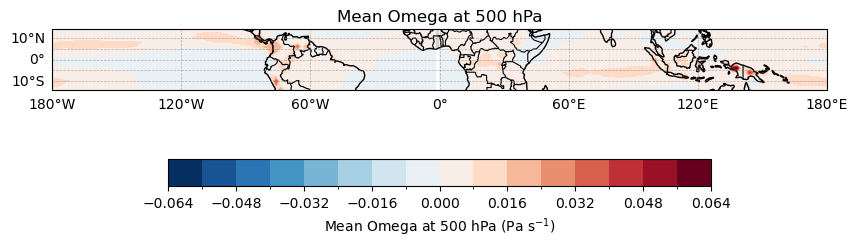

In [36]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj)

# 主图
result_plot.plot.contourf(
    ax=ax,
    x='lon',
    y='lat',
    levels=21,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),   # 数据所在坐标系
    cbar_kwargs={'label': 'Mean Omega at 500 hPa (Pa s$^{-1}$)',
                 'shrink': 0.7,
                 'orientation': 'horizontal'}
)

# 添加海岸线和国界
ax.coastlines(resolution='110m', linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)

# 添加经纬度网格线与标签
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title('Mean Omega at 500 hPa')
# plt.tight_layout()
plt.show()


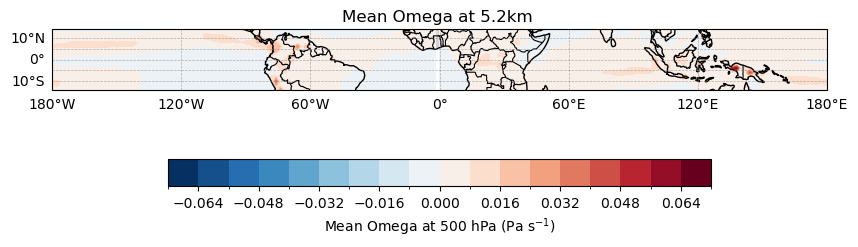

In [40]:

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj)

# 主图
wa_cntl['wa'].sel(level=67).mean(dim='time').plot.contourf(
    ax=ax,
    x='lon',
    y='lat',
    levels=21,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),   # 数据所在坐标系
    cbar_kwargs={'label': 'Mean Omega at 500 hPa (Pa s$^{-1}$)',
                 'shrink': 0.7,
                 'orientation': 'horizontal'}
)

# 添加海岸线和国界
ax.coastlines(resolution='110m', linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)

# 添加经纬度网格线与标签
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title('Mean Omega at 5.2km ')
# plt.tight_layout()
plt.show()
